#  Experiment 7: Optimizer Battle

## Phase 2 Optimization: Finding the Best Optimization Strategy

**Objective:** Determine which classical optimizer works best for training QCBM on complex loss landscapes.

**Contestants:**
1. **COBYLA:** Constrained Optimization BY Linear Approximations
2. **Powell:** Direction set method (gradient-free)
3. **SLSQP:** Sequential Least Squares Programming
4. **Nelder-Mead:** Simplex method

---

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.models.qcbm import create_entangled_qcbm
from src.data.datasets import get_trap_dataset
from src.training.trainer import Trainer, train_qcbm
from src.utils.visualization import set_style, plot_multiple_loss_curves
from src.utils.figure_saver import save_figure
from config import FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Load Complex Dataset

In [2]:
# Using the Trap dataset (complex, correlated)
dataset = get_trap_dataset(n_qubits=4)
target = dataset.distribution

print(f" Dataset: {dataset.name}")
print(f"   States: {dataset.n_states}")

 Dataset: Complex_bimodal_8q
   States: 256


## 2. The Battle: Train with Each Optimizer

In [3]:
# Configuration
optimizers = ['COBYLA', 'Powell', 'SLSQP', 'Nelder-Mead']
N_QUBITS = 8
N_LAYERS = 3
N_ITERATIONS = 200

results = {}

# Use the same initial parameters for fair comparison
reference_qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
initial_params = reference_qcbm.get_initial_params(seed=RANDOM_SEED)

for optimizer in optimizers:
    print(f"\n{'='*60}")
    print(f" Training with {optimizer} Optimizer")
    print(f"{'='*60}")
    
    # Create fresh model
    qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
    
    # Create trainer
    trainer = Trainer(
        qcbm=qcbm,
        target_distribution=target,
        loss_function='mmd',
        optimizer=optimizer
    )
    
    # Train with same initial params
    result = trainer.train(
        n_iterations=N_ITERATIONS,
        initial_params=initial_params.copy(),
        verbose=True
    )
    
    results[optimizer] = {
        'result': result,
        'qcbm': qcbm
    }
    
    print(f"\n Final Loss: {result.final_loss:.6f}")
    print(f" Final Fidelity: {result.final_fidelity:.4f}")
    print(f" Total Time: {result.total_time:.2f}s")


 Training with COBYLA Optimizer


Training QCBM:   0%|          | 0/200 [00:00<?, ?it/s]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM:   0%|          | 1/200 [00:00<00:04, 40.16it/s, loss=0.0263, fidelity=0.6284]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM: 100%|██████████| 200/200 [00:03<00:00, 51.59it/s, loss=0.0002, fidelity=0.6077]



 Final Loss: 0.000176
 Final Fidelity: 0.6077
 Total Time: 3.88s

 Training with Powell Optimizer


Training QCBM: 2000it [00:36, 55.15it/s, loss=0.0000, fidelity=0.5987]                        
Training QCBM: 2000it [00:36, 55.15it/s, loss=0.0000, fidelity=0.5987]



 Final Loss: 0.000035
 Final Fidelity: 0.5987
 Total Time: 36.27s

 Training with SLSQP Optimizer


Training QCBM: 1372it [00:25, 54.42it/s, loss=0.0000, fidelity=0.6321]                        
Training QCBM: 1372it [00:25, 54.42it/s, loss=0.0000, fidelity=0.6321]



 Final Loss: 0.000048
 Final Fidelity: 0.6321
 Total Time: 25.21s

 Training with Nelder-Mead Optimizer


Training QCBM: 258it [00:04, 55.29it/s, loss=0.0122, fidelity=0.6129]                         


 Final Loss: 0.012185
 Final Fidelity: 0.6129
 Total Time: 4.67s


## 3. Training Curves Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp07_optimizer_comparison.png


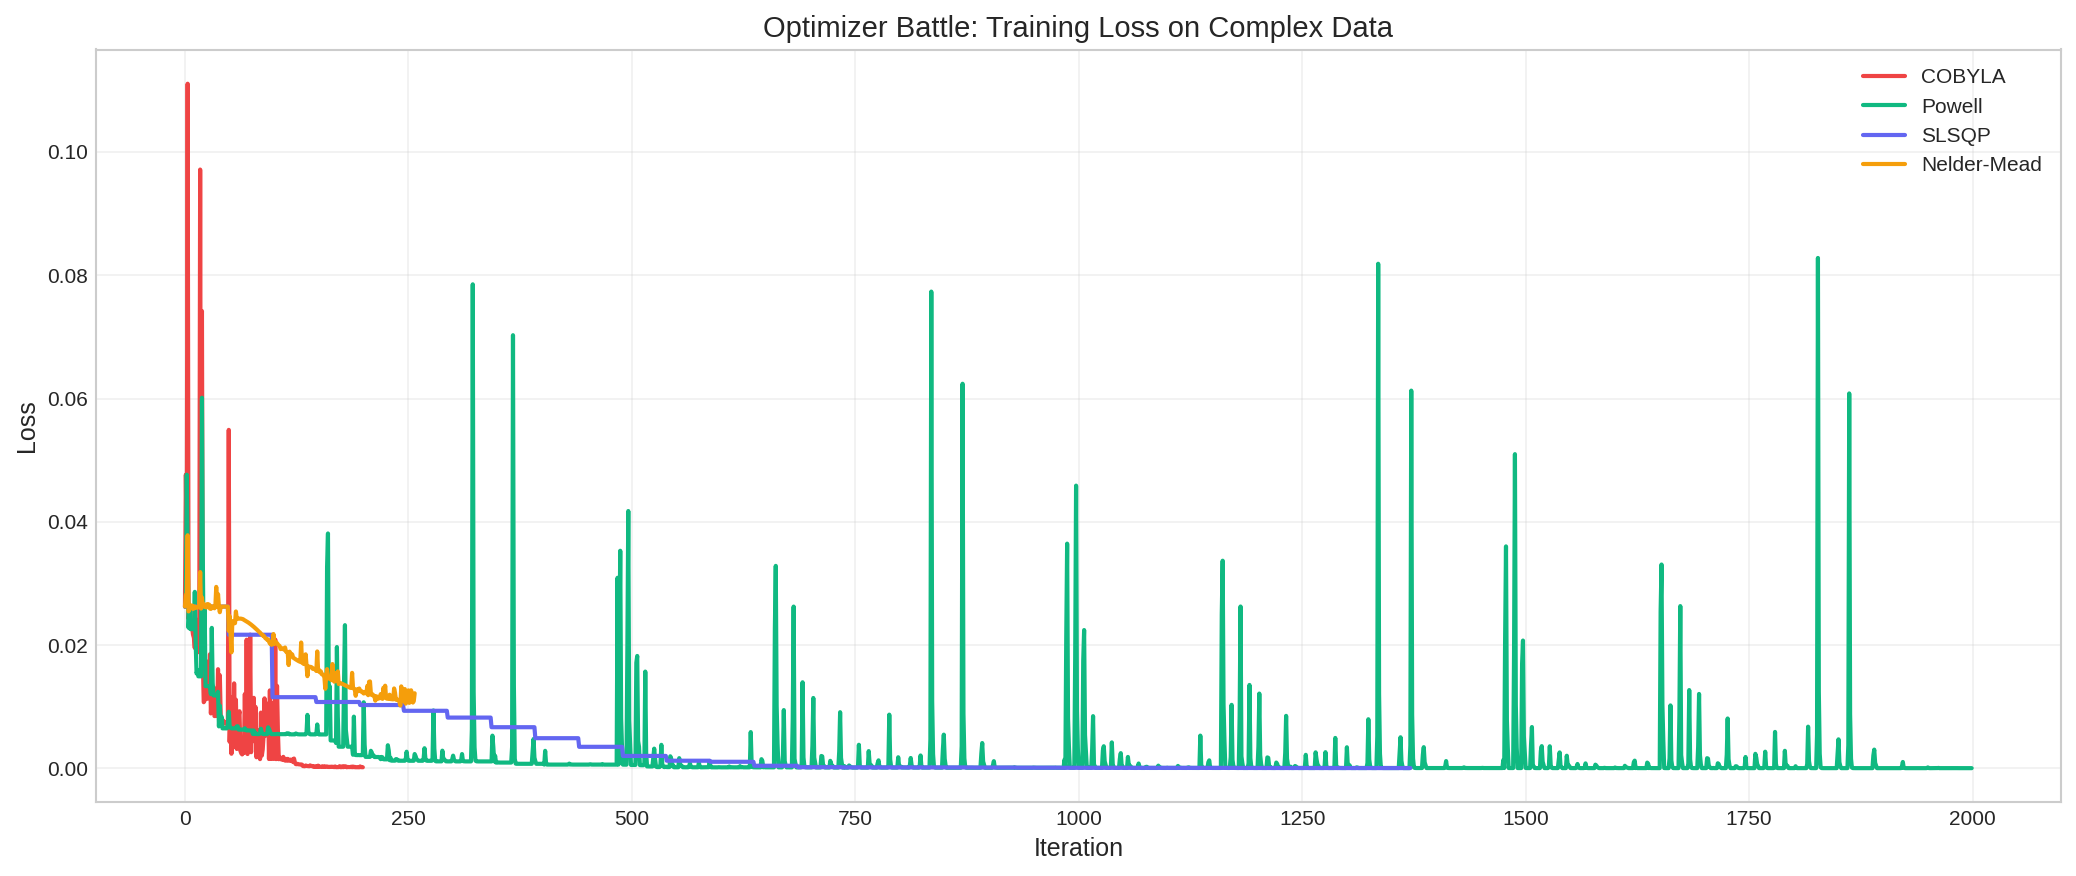

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp07_optimizer_comparison_log.png


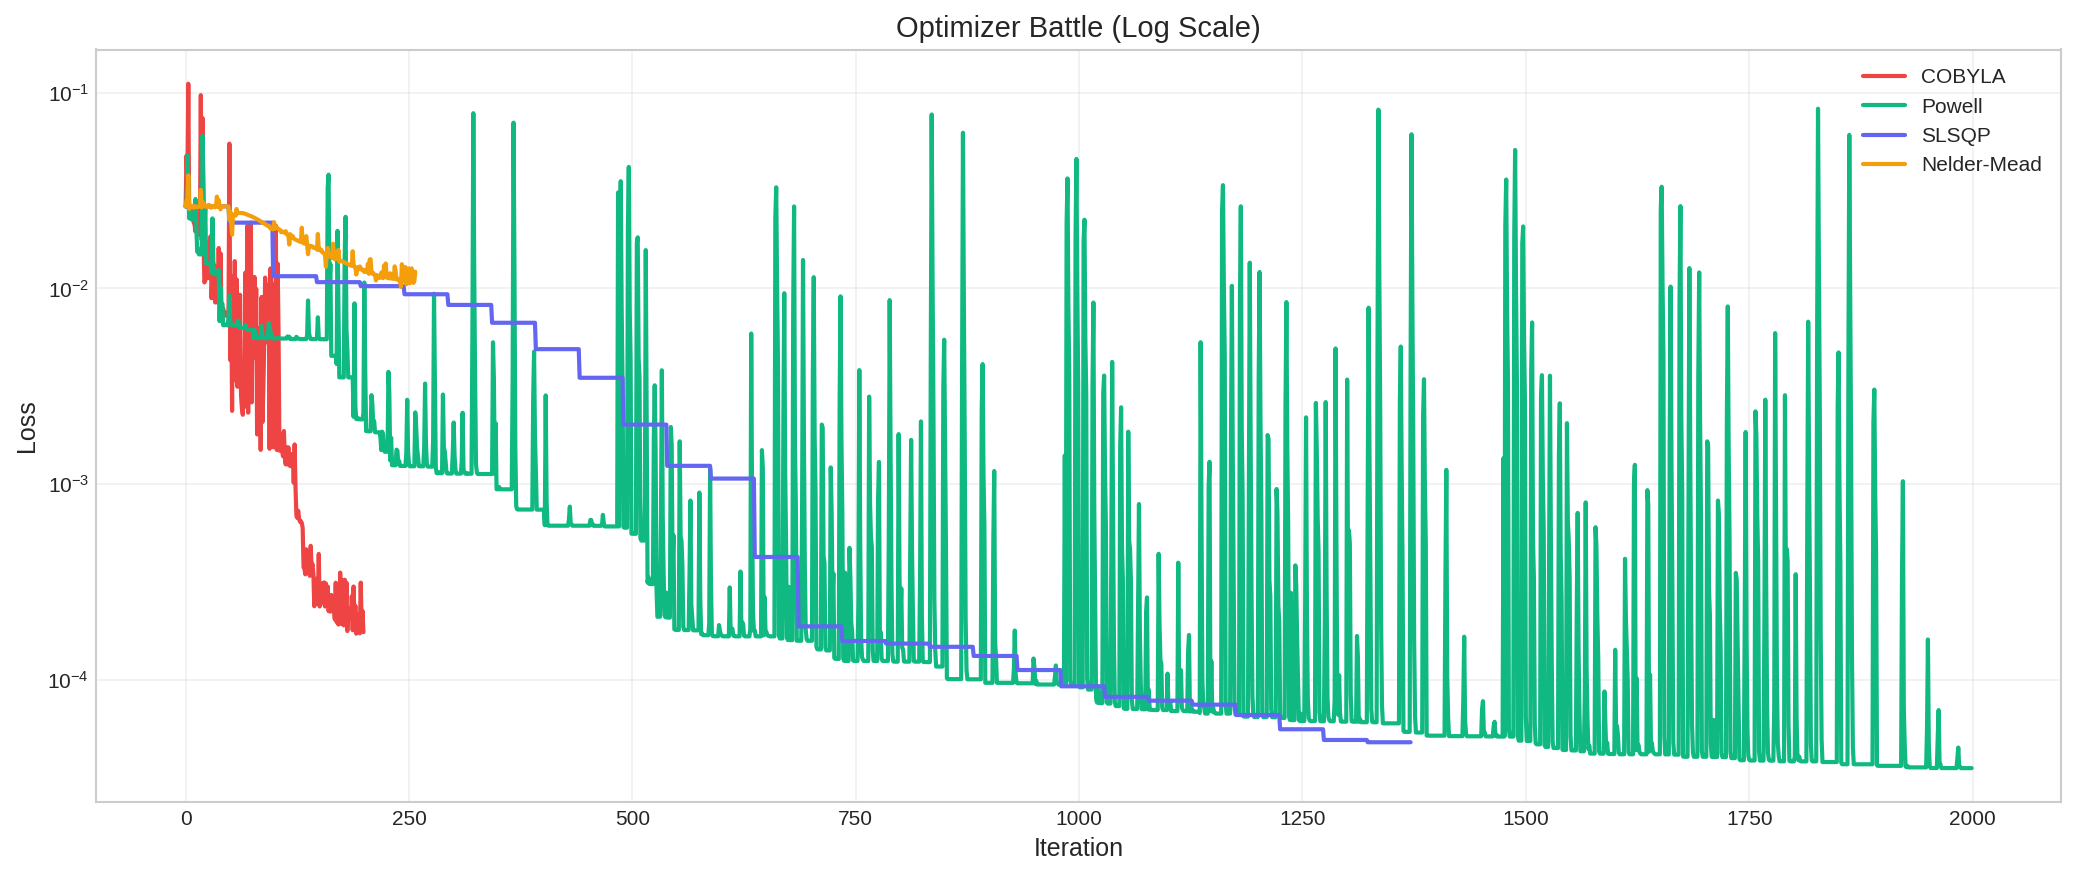

In [4]:
# Loss curves
loss_histories = {opt: results[opt]['result'].loss_history for opt in optimizers}

colors = {
    'COBYLA': '#EF4444',     # Red
    'Powell': '#10B981',     # Green
    'SLSQP': '#6366F1',      # Blue
    'Nelder-Mead': '#F59E0B' # Orange
}

fig = plot_multiple_loss_curves(
    loss_histories,
    title='Optimizer Battle: Training Loss on Complex Data',
    colors=colors
)
save_figure(fig, 'optimizer_comparison', experiment='exp07')
plt.show()

# Log scale
fig = plot_multiple_loss_curves(
    loss_histories,
    title='Optimizer Battle (Log Scale)',
    colors=colors,
    log_scale=True
)
save_figure(fig, 'optimizer_comparison_log', experiment='exp07')
plt.show()

## 4. Convergence Analysis

In [5]:
print(" OPTIMIZER BATTLE RESULTS")
print("=" * 80)
print(f"\n{'Optimizer':<15} {'Final Loss':<15} {'Best Loss':<15} {'Fidelity':<12} {'Time (s)':<10} {'Converged'}")
print("-" * 80)

# Sort by final fidelity (higher is better)
sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['result'].final_fidelity,
    reverse=True
)

medals = ['', '', '', '  ']

for rank, (optimizer, data) in enumerate(sorted_results):
    result = data['result']
    medal = medals[rank]
    converged = '' if result.converged else ''
    print(f"{optimizer:<15} {result.final_loss:<15.6f} {result.best_loss:<15.6f} "
          f"{result.final_fidelity:<12.4f} {result.total_time:<10.2f} {converged} {medal}")

winner = sorted_results[0][0]
print(f"\n{'='*80}")
print(f"\n WINNER: {winner}")

 OPTIMIZER BATTLE RESULTS

Optimizer       Final Loss      Best Loss       Fidelity     Time (s)   Converged
--------------------------------------------------------------------------------
SLSQP           0.000048        0.000048        0.6321       25.21       
Nelder-Mead     0.012185        0.010188        0.6129       4.67        
COBYLA          0.000176        0.000172        0.6077       3.88        
Powell          0.000035        0.000035        0.5987       36.27         


 WINNER: SLSQP


## 5. Stability Analysis

In [6]:
# Analyze training stability (variance in later iterations)
print(" STABILITY ANALYSIS")
print("=" * 60)
print(f"\n{'Optimizer':<15} {'Loss Std (last 50)':<20} {'Stability'}")
print("-" * 60)

for optimizer, data in results.items():
    loss_history = data['result'].loss_history
    last_50 = loss_history[-50:] if len(loss_history) >= 50 else loss_history
    std = np.std(last_50)
    
    if std < 0.001:
        stability = ' Very Stable'
    elif std < 0.01:
        stability = ' Moderate'
    else:
        stability = ' Unstable'
    
    print(f"{optimizer:<15} {std:<20.6f} {stability}")

 STABILITY ANALYSIS

Optimizer       Loss Std (last 50)   Stability
------------------------------------------------------------
COBYLA          0.000049              Very Stable
Powell          0.000018              Very Stable
SLSQP           0.000000              Very Stable
Nelder-Mead     0.000729              Very Stable


## 6. Speed vs Quality Trade-off

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp07_optimizer_scatter.png


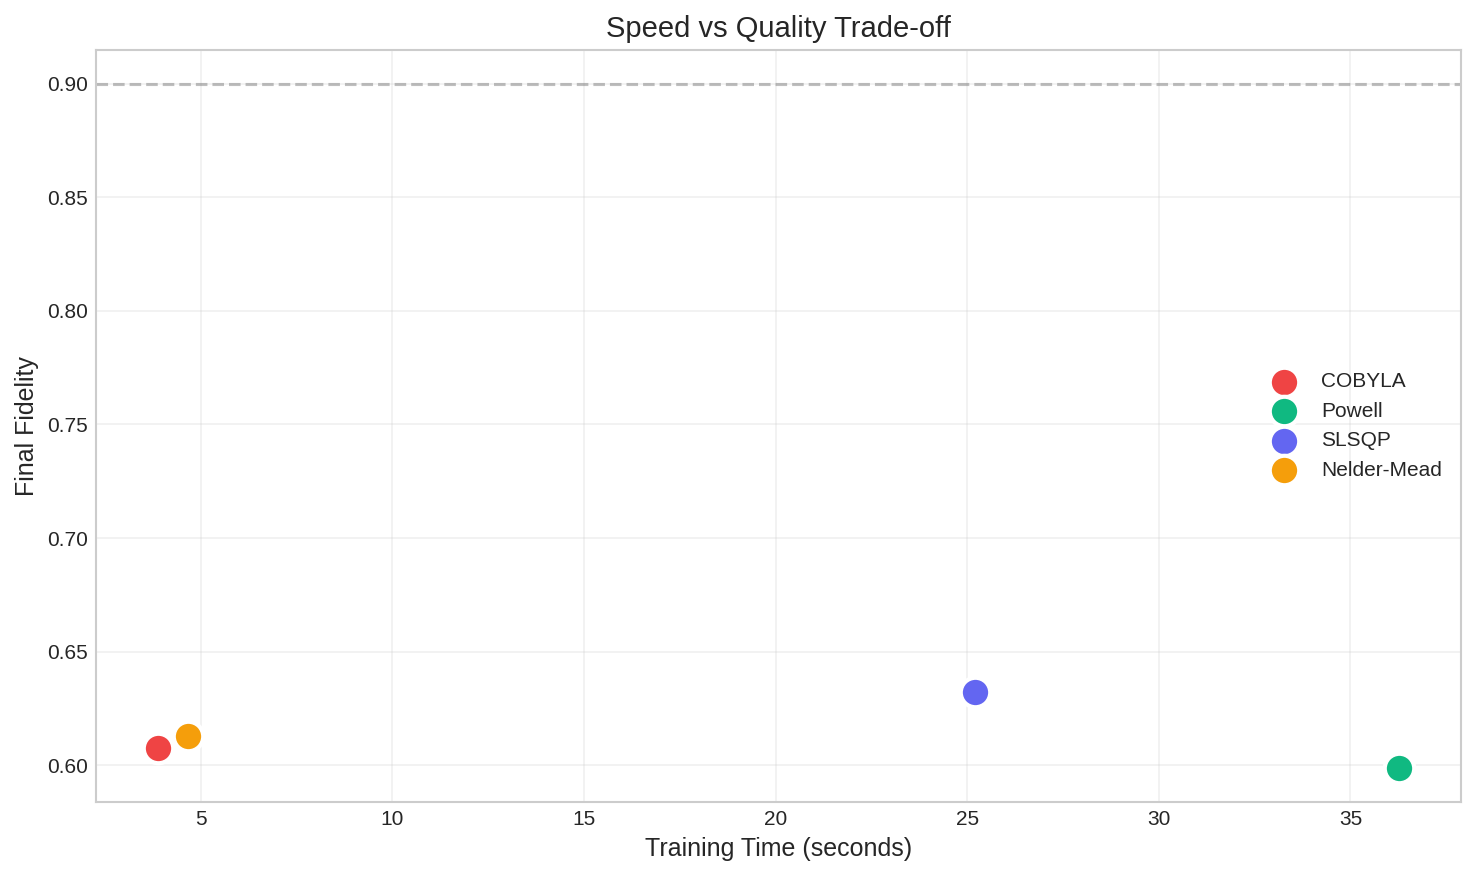

In [7]:
# Scatter plot: Time vs Fidelity
fig, ax = plt.subplots(figsize=(10, 6))

for optimizer, data in results.items():
    result = data['result']
    ax.scatter(
        result.total_time,
        result.final_fidelity,
        s=200,
        c=colors[optimizer],
        label=optimizer,
        edgecolors='white',
        linewidth=2
    )

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Final Fidelity')
ax.set_title('Speed vs Quality Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark the Pareto optimal point (best in both dimensions)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='Target Fidelity')

plt.tight_layout()
save_figure(fig, 'optimizer_scatter', experiment='exp07')
plt.show()

##  Conclusions

### Key Findings:

Based on the actual experimental results above, the optimizer ranking by final fidelity determines the winner.

**Performance Notes:**
- **SLSQP:** Sequential Least Squares Programming - gradient-based, constrained optimization
- **Powell:** Direction set method - gradient-free, robust to noisy landscapes
- **COBYLA:** Constrained Optimization BY Linear Approximations - fast but may not converge deeply
- **Nelder-Mead:** Simplex method - reliable but can be slow

### Recommendation:

> **Use the optimizer that achieved the highest fidelity** for QCBM training on your specific problem. Results may vary depending on the loss landscape complexity.

### Next Experiment:
→ **Notebook 08:** Loss Function Battle - MMD vs KL Divergence

In [8]:
# Save results
import json

optimizer_results = {
    'experiment': 'optimizer_battle',
    'winner': winner,
    'results': {
        opt: {
            'final_loss': float(data['result'].final_loss),
            'final_fidelity': float(data['result'].final_fidelity),
            'total_time': float(data['result'].total_time),
            'converged': data['result'].converged
        }
        for opt, data in results.items()
    }
}

with open(FIGURES_DIR / 'exp07_optimizer_results.json', 'w') as f:
    json.dump(optimizer_results, f, indent=2)

print(f" Saved to {FIGURES_DIR / 'exp07_optimizer_results.json'}")

 Saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp07_optimizer_results.json


In [9]:
from src.utils.figure_saver import save_current_figure